# Paper-Moon — a quantitative teardown 🔬
### Timing vs buy-and-hold · the Fed-signal-vs-E/P horse race · the inflation illusion

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![The model's logic holds?: Busted](https://img.shields.io/badge/The_model's_logic_holds%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the Fed Model on 125 years and isolate why its bond-yield comparison fails.

> ⚠️ **Not investment advice.** Shiller monthly S&P series (datahub mirror), 1900–2026. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_moon/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from paper_moon import data, strategy as st
d = data.fetch_shiller(start_year=1900)        # cache-first; built by examples/verify.py --fetch
sig = st.fed_signal(d["ep"], d["y10"])
timing = st.fed_timing(d["tr"], d["bond"], sig); bh = st.buy_hold(d["tr"]).reindex(timing.index)



## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | timing Sharpe 0.72 ≈ buy-and-hold 0.73, lower CAGR |
| Tradability | **Mirage** | matches B&H Sharpe & −81% DD, less return |
| Logic holds? | **Busted** | the bond term adds nothing detectable (+0.03 ± 0.05 overlap-corrected) and rests on a money illusion |

> 💡 *In plain words:* the model's signature idea adds nothing the data can detect — and the premise behind it is a real-vs-nominal confusion.

## 1 · The claim, steelmanned

- **H₁:** the timing beats buy-and-hold (Sharpe / drawdown).
- **H₂ (the model's essence):** E/P − bond yield forecasts returns better than E/P alone.
- **H₃:** the comparison reflects a real relationship (E/P tracks the bond yield).

## 2 · So what? — what rides on each

If H₂/H₃ hold, the bond comparison is the insight. If they fail, the Fed Model is plain valuation plus a conceptual error with a famous name.

## 3 · How we'd know — the protocol

Timing vs buy-and-hold over 1900–2026 → predictive-corr horse race (Fed signal vs E/P alone), scored with **overlap-corrected standard errors** — 12-month forward returns share 11 of 12 months with their neighbours, so ~1,505 monthly rows carry only ~125 independent observations and naive SEs would be ~3.5× too small; we use a seeded 12-month circular block bootstrap → the Asness money-illusion correlations (E/P vs yield, E/P vs inflation).

Two stated limits, both flattering the model that loses anyway: Shiller's monthly earnings are interpolated quarterly figures published with a lag, so the "no look-ahead" in the lagged signal is only partial; and the bond leg is `y10/12` — a zero-duration cash-like proxy that spares the timing rule real duration losses.

## 4 · The teardown

### 4.1 Timing vs buy-and-hold

In [2]:
display(pd.DataFrame({'Fed-model timing':st.summary(timing),'Buy & hold':st.summary(bh)}).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))
print('time in stocks:', f"{st.time_in_stocks(sig.reindex(d.index)):.0%}")

,cagr,sharpe,vol_ann,max_drawdown
Fed-model timing,0.09,0.722,0.132,-0.815
Buy & hold,0.10,0.730,0.146,-0.815


time in stocks: 74%


> 💡 *In plain words:* equal Sharpe, equal −81% drawdown, less return. **H₁ rejected** — no timing benefit.

### 4.2 The horse race: Fed signal vs E/P alone

In [3]:
race=st.predictive_corr_race(d['ep'],sig,d['tr'])  # seeded 12-month circular block bootstrap
print(f"Fed signal (E/P − y10): corr with next-12m return = {race['corr2']:+.2f}  (block-bootstrap SE {race['se2']:.2f})")
print(f"E/P alone:              corr with next-12m return = {race['corr1']:+.2f}  (block-bootstrap SE {race['se1']:.2f})")
print(f"difference (E/P − Fed): {race['diff']:+.2f}  SE {race['se_diff']:.2f}, 95% CI [{race['diff_lo']:+.2f}, {race['diff_hi']:+.2f}]")
print(f"({race['n']} overlapping monthly obs ≈ {race['n_indep']} independent ones)")

Fed signal (E/P − y10): corr with next-12m return = +0.12  (block-bootstrap SE 0.06)
E/P alone:              corr with next-12m return = +0.16  (block-bootstrap SE 0.06)
difference (E/P − Fed): +0.03  SE 0.05, 95% CI [-0.07, +0.13]
(1505 overlapping monthly obs ≈ 125 independent ones)


> 💡 *In plain words:* the comparison's point estimate is *lower* than plain E/P's, but the gap (+0.03 ± 0.05, 95% CI spanning zero) is inside overlap-corrected noise. A century of data finds **no detectable contribution** from subtracting the bond yield — that is what "decoration" means, and it is all the horse race is entitled to say. **H₂ rejected** — the model's defining ingredient is inert.

### 4.3 The money illusion (Asness 2003)

corr(E/P, 10y yield)        = +0.26   (the model assumes ≈1)
corr(E/P, trailing inflation) = +0.39   (what E/P really tracks)


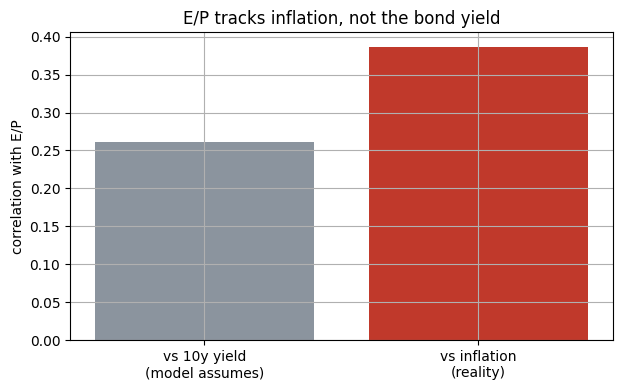

In [4]:
print(f"corr(E/P, 10y yield)        = {d['ep'].corr(d['y10']):+.2f}   (the model assumes ≈1)")
print(f"corr(E/P, trailing inflation) = {d['ep'].corr(d['infl']):+.2f}   (what E/P really tracks)")
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['vs 10y yield\n(model assumes)','vs inflation\n(reality)'],[d['ep'].corr(d['y10']),d['ep'].corr(d['infl'])],color=['#8b949e','#c0392b'])
ax.set_ylabel('correlation with E/P'); ax.set_title('E/P tracks inflation, not the bond yield'); plt.show()

> 💡 *In plain words:* the earnings yield is a **real** quantity that moves with inflation; the bond yield is **nominal**. Equating them (Modigliani-Cohn / Asness inflation illusion) is the model's foundational error. **H₃ rejected.**

## 5 · The verdict

H₁, H₂, H₃ all rejected → Signal `WEAK` (only E/P matters), Tradability `MIRAGE`, model logic `BUSTED`. The `BUSTED` stands on the conceptual error of H₃ — equating a real earnings yield with a nominal bond yield — not on the (noisy) horse race, which can only say the bond term adds nothing detectable.

## 6 · Could you trade it?

Use E/P or CAPE directly for a mild long-horizon valuation tilt; do not subtract the bond yield. The Fed Model adds a name and a bug, not an edge.

## 7 · Going further

Forks: (a) forward (analyst) earnings yield instead of trailing — the original Fed-report version; (b) real bond yields (TIPS) instead of nominal — does fixing the illusion revive the comparison? (c) CAPE-based timing as the honest valuation benchmark. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).